# Titanitron

This cell imports dependencies 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Load the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


There is some missing information in  the train dataset, so this next cell displays them.

In [3]:
  # Basic information about the dataset
print("Dataset Info:")
print(train_df.info())
print("\nMissing values:")
print(train_df.isnull().sum())
print("\nSurvival statistics:")
print(train_df['Survived'].value_counts())
print(f"Survival rate: {train_df['Survived'].mean():.3f}")

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked      

Since the passengerid and ticket columns are unneccessary, this next cell removes them from the dataframe.

In [ ]:
train_df.drop(columns=['PassengerId', 'Ticket'], inplace=True)
train_df.info()
train_df.head(10)

This cell fills the missing embarked values with the mode of the embarked category.

In [ ]:
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)
train_df.isnull().sum()

To fill the missing values for age, each missing value is filled with the median value for each respective gender and class.

In [ ]:
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(
lambda x: x.fillna(x.median())
)

After plotting training data, we found a pattern where younger people had a higher survival rate.

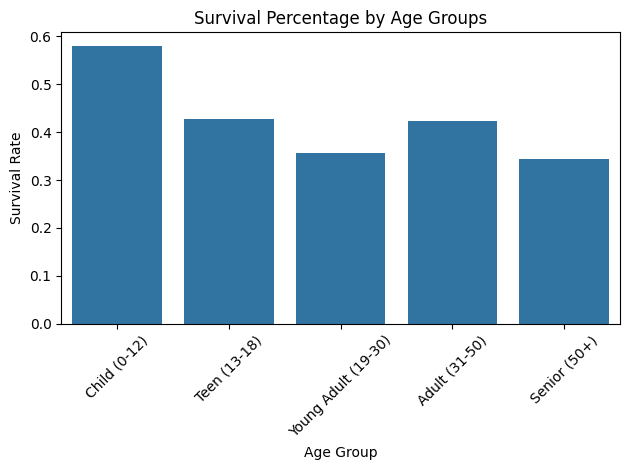

In [4]:
# Age analysis show that young people have higher survival rate.
# Survival percentage by meaningful age groups
train_viz2 = train_df.copy()
train_viz2['Age_Group'] = pd.cut(train_viz2['Age'],

bins=[0, 12, 18, 30, 50, 80],
labels=['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-30)',
'Adult (31-50)', 'Senior (50+)'])
sns.barplot(data=train_viz2, x='Age_Group', y='Survived', ci=None)
plt.title('Survival Percentage by Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Since the cabin category is missing too much data, it is dropped from the dataset.

In [ ]:
train_df.drop(columns=['Cabin'], inplace=True)

Another pattern that we found was the people with a higher social status 

In [ ]:
sns.countplot(data=train_df, x='Pclass', hue='Survived')
plt.title('Survival by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

Ordinally encodes the class category

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
# Ordinal encoding for ordinal categories
encoder = OrdinalEncoder(categories=[['1', '2', '3']])
train_df['Pclass_encoded'] = encoder.fit_transform(train_df[['Pclass']])
train_df.drop(columns=['Pclass'], inplace=True)
train_df.head(10)